In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# State numbers exactly as in the assignment
states = np.array([1, 2, 3, 4, 5])

# Transition probability matrix P
# Rows and columns correspond to states 1, 2, 3, 4, 5
P = pd.DataFrame(
    data=[
        [0.9915, 0.0050, 0.0025, 0.0000, 0.0010],
        [0.0000, 0.9860, 0.0050, 0.0040, 0.0050],
        [0.0000, 0.0000, 0.9920, 0.0030, 0.0050],
        [0.0000, 0.0000, 0.0000, 0.9910, 0.0090],
        [0.0000, 0.0000, 0.0000, 0.0000, 1.0000]
    ],
    index=states,
    columns=states
)

P


1    1.0
2    1.0
3    1.0
4    1.0
5    1.0
dtype: float64

In [5]:
def simulate_one_woman(P, rng):
    """
    Simulate one woman starting in state 1 until death.

    Returns:
        lifetime: number of months until death
        path: list of visited states using assignment numbering 1, 2, 3, 4, 5
        local_recurrence: True if she ever enters state 2 or state 4
    """

    current_state = 1
    lifetime = 0
    path = [current_state]
    local_recurrence = False

    while current_state != 5:
        transition_probabilities = P.loc[current_state].values

        next_state = rng.choice(states, p=transition_probabilities)

        lifetime += 1
        current_state = next_state
        path.append(current_state)

        # Local recurrence means entering state 2 or state 4
        if current_state in [2, 4]:
            local_recurrence = True

    return lifetime, path, local_recurrence

In [6]:
# Simulate 1000 women
rng = np.random.default_rng(seed=123)

n_women = 1000

lifetimes = []
local_recurrences = []
paths = []

for _ in range(n_women):
    lifetime, path, local_recurrence = simulate_one_woman(P, rng)

    lifetimes.append(lifetime)
    local_recurrences.append(local_recurrence)
    paths.append(path)

results = pd.DataFrame({
    "lifetime_months": lifetimes,
    "local_recurrence": local_recurrences,
    "path": paths
})

results.head()

,lifetime_months,local_recurrence,path
0,775,True,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,3,False,"[1, 1, 1, 5]"
2,241,True,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,406,True,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,234,False,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [7]:
# Summary statistics for lifetimes
results["lifetime_months"].describe()

count    1000.00000
mean      259.75300
std       191.92273
min         1.00000
25%       118.75000
50%       213.00000
75%       352.00000
max      1481.00000
Name: lifetime_months, dtype: float64

In [8]:
# Proportion of women whose cancer eventually reappears locally
proportion_local_recurrence = results["local_recurrence"].mean()

print(f"Proportion with eventual local recurrence: {proportion_local_recurrence:.4f}")
print(f"Percentage with eventual local recurrence: {100 * proportion_local_recurrence:.2f}%")

Proportion with eventual local recurrence: 0.7060
Percentage with eventual local recurrence: 70.60%


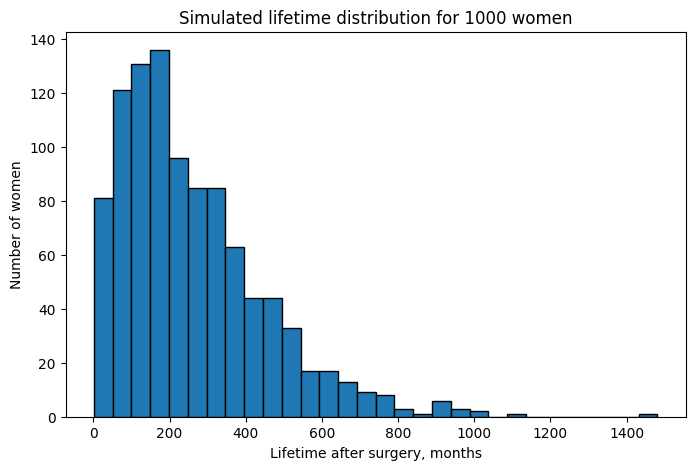

In [9]:
# Histogram of lifetime distribution
plt.figure(figsize=(8, 5))
plt.hist(results["lifetime_months"], bins=30, edgecolor="black")
plt.xlabel("Lifetime after surgery, months")
plt.ylabel("Number of women")
plt.title("Simulated lifetime distribution for 1000 women")
plt.show()